# ***EfficientNetB0***

In [ ]:
import tensorflow as tf
print("availanble devices:", tf.config.list_physical_devices('GPU'))
print("GPU available:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


availanble devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU available: True


## Stage 1: Preparation and standardisation of conditions (Reproducibility)

In [ ]:
# 1.1 import libraries

import numpy as np
import tensorflow as tf
import random
import os

In [ ]:
# 1.2 Setting the seed (random seed)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED) # убирает скрытую случайность Python
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Step 2: Loading and preparing the data

## Step 2: Loading data

In [ ]:
# 2.1 Setting the main parameters

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset"

dataset


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset/dataset"

test  train  val


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset/dataset/train"

overripe  ripe	unripe


In [ ]:
# 2.2 Пути к данным

train_dir = "/content/drive/MyDrive/banana_dataset/dataset/train"
val_dir = "/content/drive/MyDrive/banana_dataset/dataset/val"
test_dir = "/content/drive/MyDrive/banana_dataset/dataset/test"

print(os.path.exists(train_dir))
print(os.path.exists(val_dir))
print(os.path.exists(test_dir))

True
True
True


In [ ]:
# 2.3 Uploading images

print("------------------ TRAIN: ------------------")
train_ds = tf.keras.preprocessing.image_dataset_from_directory( #creates an image dataset from folders
    train_dir,                          # path to the “train” folder
    seed=SEED,                          # ensures that the images appear in the same order
    image_size=(IMG_HEIGHT, IMG_WIDTH), # resizes each image to 224px
    batch_size=BATCH_SIZE,              # collects 32 images at a time
    label_mode='categorical'
    # “categorical” -> means we have several classes, and the labels will be in the form of one-hot encoding, e.g.: unripe - [1, 0, 0], ripe - [0, 1, 0], overripe - [0, 0, 1]
)

print("------------------ VALIDATION: ------------------")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("----------------- TEST: ------------------")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False

)

------------------ TRAIN: ------------------
Found 6734 files belonging to 3 classes.
------------------ VALIDATION: ------------------
Found 1825 files belonging to 3 classes.
----------------- TEST: ------------------
Found 1401 files belonging to 3 classes.


In [ ]:
# 2.4 Class verification (the order is important as it is used in the confusion matrix)

class_names = train_ds.class_names
print(class_names)

print("Order of classes: ")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")


['overripe', 'ripe', 'unripe']
Order of classes: 
0 -> overripe
1 -> ripe
2 -> unripe


In [ ]:
class_encoding = {
    class_name: tf.one_hot(i, depth=len(class_names))
    for i, class_name in enumerate(class_names)
}

for class_name, encoding in class_encoding.items():
    print(f"{class_name}: {encoding.numpy()}")

overripe: [1. 0. 0.]
ripe: [0. 1. 0.]
unripe: [0. 0. 1.]


In [ ]:
# 2.5 Checking the number of images by class

# Objective:
# to ensure that the data is distributed correctly
# to check for any imbalance
# to determine how many examples there are in each class
# to assess whether there is sufficient data for training

import os     #library for working with folders and files

def count_images(directory):     # Function to count the number of images in each class folder
    counts = {}                  # store the result as a dictionary:{'unripe': 620, ...}

    for class_name in os.listdir(directory):               # Iterate through each item in the folder (unripe, ripe, overripe)
        class_path = os.path.join(directory, class_name)   # create the full path to the class folder

        if os.path.isdir(class_path):                # Check that this is indeed a folder and not a file
            counts[class_name] = len(os.listdir(class_path))    # count the number of files (images) in the class folder

    return counts       # return a dictionary containing the number of images

print("TRAIN SET:", count_images(train_dir))

print("VALIDATION SET:", count_images(val_dir))
print("TEST SET:", count_images(test_dir))

TRAIN SET: {'overripe': 4299, 'ripe': 1815, 'unripe': 620}
VALIDATION SET: {'unripe': 184, 'overripe': 1326, 'ripe': 315}
TEST SET: {'overripe': 1010, 'ripe': 211, 'unripe': 180}


In [ ]:
# 2.5 Table visualisation

import pandas as pd   # library for tables

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

df = pd.DataFrame({
    "Class": ["overripe", "ripe", "unripe"],
    "Train count": [train_counts.get("overripe", 0),
                    train_counts.get("ripe", 0),
                    train_counts.get("unripe", 0)],
    "Validation Count": [val_counts.get("overripe", 0),
                         val_counts.get("ripe", 0),
                         val_counts.get("unripe", 0)],
    "Test Count": [test_counts.get("overripe", 0),
                   test_counts.get("ripe", 0),
                   test_counts.get("unripe", 0)]
})

df

,Class,Train count,Validation Count,Test Count
0,overripe,4299,1326,1010
1,ripe,1815,315,211
2,unripe,620,184,180


## Шаг 3: Оптимизация данных
 - Цель: сделать загрузку данных быстрой и стабильной, чтобы
   -  GPU не простаивал
   -  обучение шло в 2-3 раза быстрее

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE   # AUTOTUNE allows TensorFlow to automatically select the optimal number of threads

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# cache() – stores data in memory after the first pass so that it does not need to be re-read from disk in subsequent epochs, ensuring faster training
# prefetch() – loads the next batch in advance whilst the GPU is training

## Step 4: Class balancing for overripe/ripe/unripe
 - Goal: to compensate for class imbalances in the training sample so that:
   -  the model does not ignore the rare class (unripe)
   -  errors on rare classes are penalised more severely
   -  training is fair

In [ ]:
# Number of images in each class in train_ds
counts = {
    0: 4299,    # overripe
    1: 1815,   # ripe
    2: 620    # unripe
}

N = sum(counts.values())   # total number of images
K = len(counts)            # number of classes

class_weights = {}

for cls, n_i in counts.items():
    class_weights[cls] = N / (K * n_i)

class_weights


{0: 0.5221369310692409, 1: 1.236730945821855, 2: 3.620430107526882}

# Stage 3: The architecture of the EfficientNetB0 model

## Step 5: Data augmentation
 - Goal: to make the model robust to changes in image perspective and orientation, so that:
   -  it does not memorise specific photos
   -  it generalises better to new images
   -  re-training is minimised

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # random reflection
    layers.RandomRotation(0.1),       # small turn to 10%
    layers.RandomZoom(0.1),           # small increase
    layers.RandomBrightness(0.2),     # changing brightness(resistance to light)
    layers.RandomContrast(0.2),       # changing the contrast(resistance to camera quality)
])

## Step 6: Base Model (EfficientNetB0)
 - Objective: to integrate the pre-trained EfficientNetB0 model as a feature extractor in order to:
   - leverage ImageNet knowledge (transfer learning)
   - avoid training the network from scratch
   - reduce the risk of training
   - speed up training

We ONLY connect the base model and freeze it

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",        # We use weights trained on ImageNet (capable of detecting: edges, shapes, textures)
    include_top=False,         # We remove the standard classification part (leaving only feature extraction—we need image features): we don’t need ‘cat’, ‘dog’ or ‘car’
    input_shape=(224, 224, 3)
)

base_model.trainable = False    # Avoid overfitting the ImageNet dataset (train only the head first)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


What the Base_model currently consists of:
- a 224x224 image
- EfficientNetB0 (frozen)
- a feature map

THE MODEL DOES NOT YET MAKE DECISIONS; IT ONLY DESCRIBES THE IMAGE

EfficientNetB0, pre-trained on ImageNet, was used as a base model for feature extraction.
The top classification layers were removed, and all base model weights were frozen at this stage

## Step 7: HEAD (model head) – determines WHICH class the data belongs to
- Objective: to add a classification layer on top of EfficientNetB0 in order to:
 - convert the extracted features into a decision across 3 classes
 - adapt the pre-trained network to my task of BANANA RIPENESS
 - prepare the model for training

Here we assemble the complete architecture

Without the head, EfficientNetB0 cannot say:
 - overripe
 - ripe
 - unripe

ANALOGY:
- EfficientNetB0 = eyes + brain
- Head = mouth, which speaks the answer

In [ ]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)             # Augmentation is applied; this only works during dataset training

x = base_model(x, training=False)       # Pass the image through EfficientNetB0 -> training=False: this locks in BatchNormalisation, does not update the statistics, and preserves the ImageNet knowledge (this is important for training stability)

x = layers.GlobalAveragePooling2D()(x)  # takes the average value for each channel and converts the 3D feature map into a 1D vector (GAP reduces overfitting)
x = layers.Dropout(0.4)(x)            # It randomly ‘switches off’ 40% of the neurons; the model does not rely on a single feature, so that it thinks rather than simply memorising (cramming)

outputs = layers.Dense(3, activation="softmax")(x) # 3 neurons = 3 classes, activation="softmax" -> returns probabilities ([0.1, 0.8, 0.1] -> 10%, 80%, 10%)

model = models.Model(inputs, outputs)   # combines everything into a single model

# Now we have:
# input
# base model
# head
# output

A custom classification head consisting of Global Average Pooling, Dropout, and a Dense softmax layer was added on top of the EfficientNetB0 base model to perform three-class banana ripeness classification

# Step 4: Training the model

## Step 8: STAGE-1 Training: WARM UP
 - Goal:
  - to begin training without risk
  - to train only the model’s head
  - not to change the EfficientNetB0 weights
  - to obtain stable metrics

In [ ]:
# 8.1 Checking for freezing

base_model.trainable = False

In [ ]:
# 8.2 Compiling the model (Stage 1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # learning speed
    loss="categorical_crossentropy",                        # for 3 classes (one-hot encoding)
    metrics=["accuracy"]              # core metric
)

In [ ]:
# 8.3 Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # monitoring the error during validation
    patience=5,                # waiting for 5 epochs without improvement
    restore_best_weights=True  # return the best weights
)


In [ ]:
# 8.4 Starting training (STAGE-1)


history_stage1 = model.fit(
    train_ds,                 # training data
    validation_data=val_ds,   # validation
    epochs=50,                # max epochs
    class_weight=class_weights,  # class balancing
    callbacks=[early_stop]
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1575s 7s/step - accuracy: 0.8693 - loss: 0.3478 - val_accuracy: 0.8805 - val_loss: 0.2907
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.9307 - loss: 0.1649 - val_accuracy: 0.8975 - val_loss: 0.2387
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9348 - loss: 0.1377 - val_accuracy: 0.9096 - val_loss: 0.2067
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9399 - loss: 0.1301 - val_accuracy: 0.9003 - val_loss: 0.2340
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9424 - loss: 0.1213 - val_accuracy: 0.9096 - val_loss: 0.2030
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9437 - loss: 0.1126 - val_accuracy: 0.9019 - val_loss: 0.2246
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9465 - loss: 0.1102 - val_accuracy: 0.9063 - val_loss: 0.2156
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9442 - loss: 0.1071 - 

In [ ]:
# Find the best epoch
import numpy as np

best_epoch = np.argmin(history_stage1.history['val_loss']) + 1
best_val_loss = np.min(history_stage1.history['val_loss'])
best_val_acc = history_stage1.history['val_accuracy'][best_epoch - 1]

print("Best epoch:", best_epoch)
print("Best val_loss:", best_val_loss)
print("Best val_accuracy:", best_val_acc)

Best epoch: 5
Best val_loss: 0.20298664271831512
Best val_accuracy: 0.9095890522003174


In [ ]:
# MAximum accuracy

max_val_acc = max(history_stage1.history['val_accuracy'])
print("Maximum val_accuracy:", max_val_acc)


Maximum val_accuracy: 0.9095890522003174


In [ ]:
# check that the model has been saved (ModelCheckpoint)
import os

os.path.exists('/content/drive/MyDrive/best_banana_model_TL.keras')


True

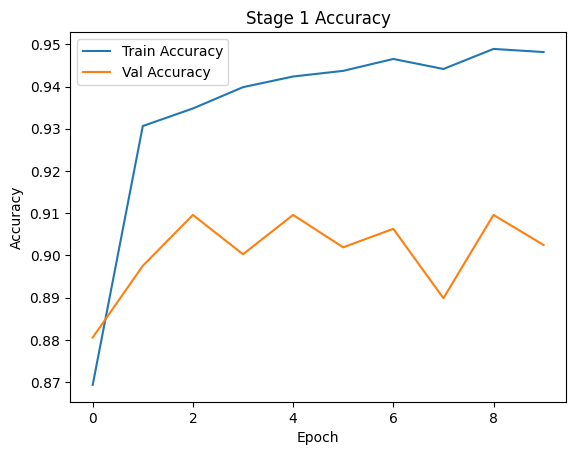

In [ ]:
# ACCURACY (STAGE-1)

import matplotlib.pyplot as plt

plt.plot(history_stage1.history['accuracy'], label='Train Accuracy')
plt.plot(history_stage1.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Stage 1 Accuracy')
plt.show()


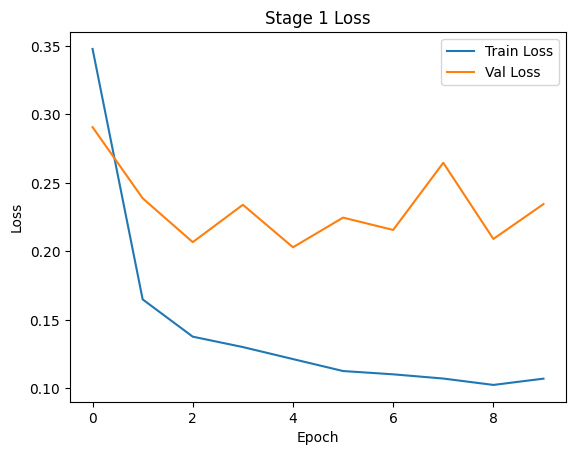

In [ ]:
# LOSS (STAGE-1)

plt.plot(history_stage1.history['loss'], label='Train Loss')
plt.plot(history_stage1.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Stage 1 Loss')
plt.show()


## Step 9: Stage 2 (Top-tuning)

 - Objective: to slightly fine-tune the EfficientNetB0 features for bananas without compromising performance on ImageNet:
   - Unfreeze ONLY the final block of EfficientNetB0
   - Reduce the learning rate
   - Perform fine-tuning

Stage 1 → the model has learnt to classify

Stage 2 → the model is learning to "see" the banana peel more clearly (spots, texture)

In [ ]:
# STEP 9.1  Unfreeze the last block of EfficientNetB0


base_model.trainable = True  # Training the base model

len(base_model.layers)   # see how many layers there are in EfficientNetB0

238

In [ ]:
# Training the base model
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
# STEP 9.2 - Recompiling the model

# goal: to fine-tune the unfrozen layers carefully without compromising the ImageNet knowledge.

model.compile(                             # prepare the model for training
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),     # 1e-4 (1e-4 = 0.0001) → less than in Stage 1 (this is SLOW and ACCURATE learning)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# STEP 9.3 — STARTING THE TRAINING (STAGE 2)

history_stage2 = model.fit(  #model.fit - start training
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# history_stage2 =
# we store the training history
# this will contain:
# loss
# accuracy
# val_loss
# val_accuracy

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.9407 - loss: 0.1375 - val_accuracy: 0.9386 - val_loss: 0.1472
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9565 - loss: 0.0927 - val_accuracy: 0.9151 - val_loss: 0.2252
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9621 - loss: 0.0748 - val_accuracy: 0.9101 - val_loss: 0.2480
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9627 - loss: 0.0721 - val_accuracy: 0.9145 - val_loss: 0.2155
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.9691 - loss: 0.0573 - val_accuracy: 0.9107 - val_loss: 0.2640
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9704 - loss: 0.0534 - val_accuracy: 0.9293 - val_loss: 0.2161


In [ ]:
history_stage2.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
import numpy as np

best_epoch_stage2 = np.argmin(history_stage2.history['val_loss']) + 1
best_val_loss_stage2 = np.min(history_stage2.history['val_loss'])
best_val_acc_stage2 = history_stage2.history['val_accuracy'][best_epoch_stage2 - 1]

print("Stage 2 — best epoch:", best_epoch_stage2)
print("Stage 2 — best val_loss:", best_val_loss_stage2)
print("Stage 2 — best val_accuracy:", best_val_acc_stage2)


Stage 2 — best epoch: 1
Stage 2 — best val_loss: 0.14719493687152863
Stage 2 — best val_accuracy: 0.9386301636695862


In [ ]:
print("Stage 2 — maximum val_accuracy:",
      max(history_stage2.history['val_accuracy']))

Stage 2 — maximum val_accuracy: 0.9386301636695862


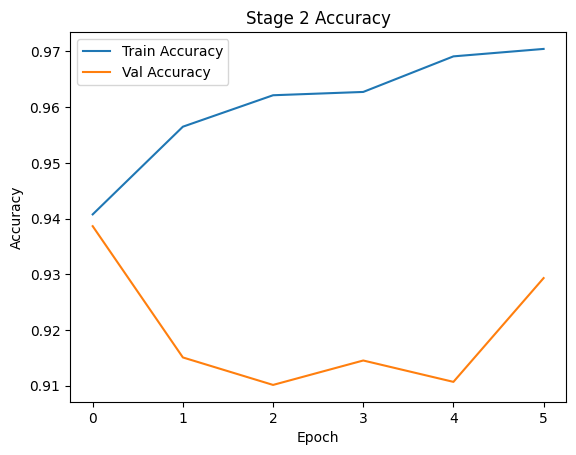

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_stage2.history['accuracy'], label='Train Accuracy')
plt.plot(history_stage2.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 2 Accuracy')
plt.legend()
plt.show()


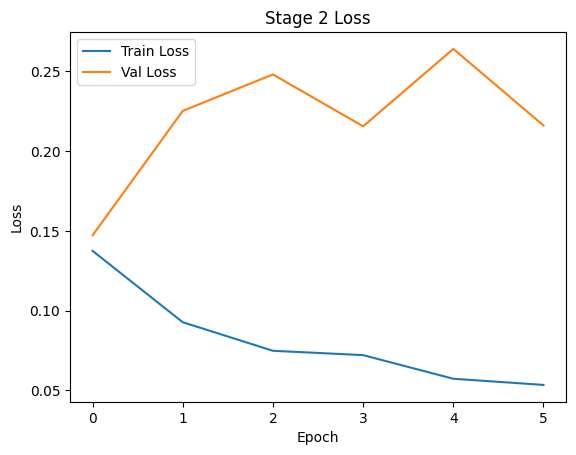

In [ ]:
plt.plot(history_stage2.history['loss'], label='Train Loss')
plt.plot(history_stage2.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stage 2 Loss')
plt.legend()
plt.show()


## Step 10: Moving on to testing
 - Objective:
   -  to test the model’s generalisation ability:
      -  how it performs on new images it has NEVER seen before.

In [ ]:
# STEP 10.1 — Preparation: let’s make sure we’re choosing the BEST Stage 2 model

In [ ]:
# STEP 10.1 — Evaluating the model on test_ds

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


44/44 ━━━━━━━━━━━━━━━━━━━━ 258s 6s/step - accuracy: 0.9179 - loss: 0.2059
Test Loss: 0.20585831999778748
Test Accuracy: 0.9179157614707947


In [ ]:
# STEP 10.2 — Obtaining predictions (for F1 and the confusion matrix)

import numpy as np

# Probability predictions
y_pred_probs = model.predict(test_ds)

# Converting probabilities to class numbers
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])


44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step


In [ ]:
# ШАГ 10.3 — True labels test set
y_true = np.concatenate([labels.numpy().argmax(axis=1) for _, labels in test_ds])


In [ ]:
# ШАГ 10.4 — Classification Report (Macro F1)

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

    overripe       1.00      0.89      0.94      1010
        ripe       0.65      0.98      0.78       211
      unripe       0.98      0.99      0.99       180

    accuracy                           0.92      1401
   macro avg       0.88      0.96      0.90      1401
weighted avg       0.94      0.92      0.92      1401



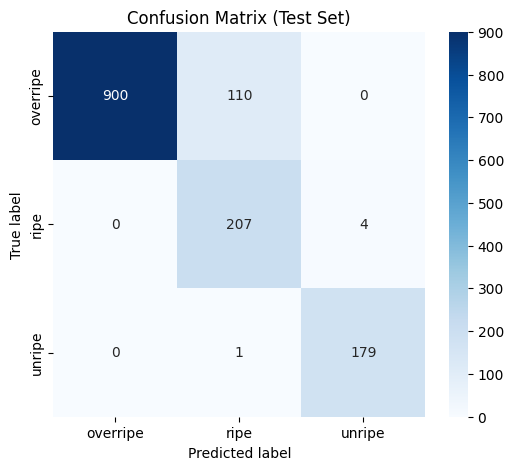

In [ ]:
# Шаг 10.5: Confusion Matrix


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Experiment: Stage 3

The goal: to check if the quality will improve if the entire network is allowed to adapt a little to bananas.

In [ ]:
# 11.1 Stage 3 - Full Fine-Tuning

base_model.trainable = True              # Unfreeze the entire base model (all 238 layers can now be trained)


In [ ]:
# 11.2 Recompiling the model (VERY IMPORTANT)

# Objective: to inform Keras that different layers are now being trained, and to use a different learning rate

model.compile(                                              # Keras rebuilds the training graph (if you do not recompile, the changes to `trainable = True` will not take effect)
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # very small learning_rate to avoid corrupting the ImageNet weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 11.3 Starting Stage 3 training

# Objective: to check whether the model improves if the ENTIRE network is trained

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.9554 - loss: 0.0964 - val_accuracy: 0.9315 - val_loss: 0.1682
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.9580 - loss: 0.0846 - val_accuracy: 0.9299 - val_loss: 0.1729
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9544 - loss: 0.0892 - val_accuracy: 0.9255 - val_loss: 0.1848
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9562 - loss: 0.0892 - val_accuracy: 0.9255 - val_loss: 0.1853
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.9562 - loss: 0.0846 - val_accuracy: 0.9277 - val_loss: 0.1815


In [ ]:
# Checking what we have saved

history_stage3.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# Finding the best epoch for STAGE 3

import numpy as np

best_epoch_stage3 = np.argmin(history_stage3.history['val_loss']) + 1
best_val_loss_stage3 = np.min(history_stage3.history['val_loss'])
best_val_acc_stage3 = history_stage3.history['val_accuracy'][best_epoch_stage3 - 1]

print("Stage 3 - the best epoch:", best_epoch_stage3)
print("Stage 3 - the best validation loss:", best_val_loss_stage3)
print("Stage 3 - the best validation accuracy:", best_val_acc_stage3)

Stage 3 - the best epoch: 1
Stage 3 - the best validation loss: 0.16821756958961487
Stage 3 - the best validation accuracy: 0.931506872177124


Graphics for STAGE 3(Train + Validation)

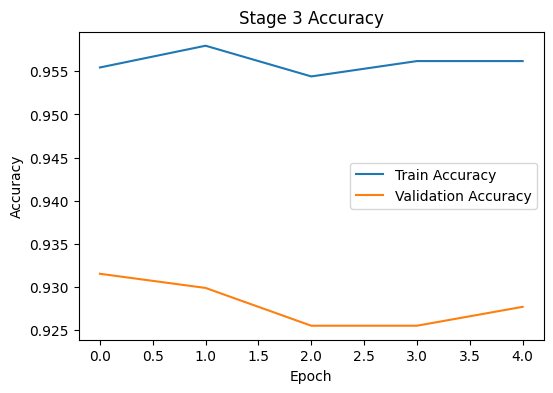

In [ ]:
# ACCURACY

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_stage3.history['accuracy'], label='Train Accuracy')
plt.plot(history_stage3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 3 Accuracy')
plt.legend()
plt.show()

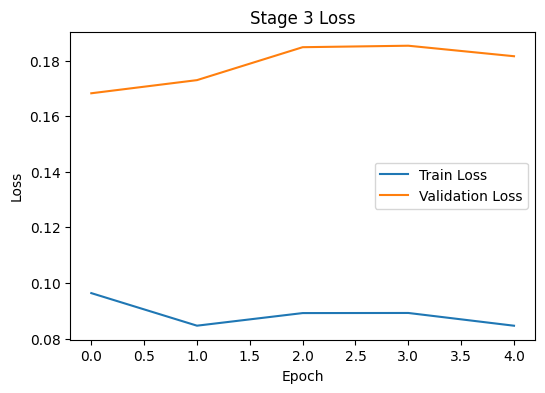

In [ ]:
# LOSS

plt.figure(figsize=(6, 4))
plt.plot(history_stage3.history['loss'], label='Train Loss')
plt.plot(history_stage3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stage 3 Loss')
plt.legend()
plt.show()

## ШАГ 12: Testing on test set(STAGE 3)

In [ ]:
test_loss_3, test_acc_3 = model.evaluate(test_ds)

print("Stage 3 Test Loss:", test_loss_3)
print("Stage 3 Test Accuracy:", test_acc_3)

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9129 - loss: 0.2420
Stage 3 Test Loss: 0.2419721633195877
Stage 3 Test Accuracy: 0.9129193425178528


In [ ]:
import numpy as np

# Probability predictions
y_pred_probs_3 = model.predict(test_ds)

# Class with the highest probability
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

# True labels
y_true_3 = np.concatenate([
    np.argmax(y, axis=1) for x, y in test_ds
])

44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step


In [ ]:
# CLASSIFICATION REPORT FOR STAGE 3(test set)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_3,
        y_pred_3,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    overripe       1.00      0.88      0.94      1010
        ripe       0.64      0.99      0.77       211
      unripe       0.98      0.99      0.99       180

    accuracy                           0.91      1401
   macro avg       0.87      0.95      0.90      1401
weighted avg       0.94      0.91      0.92      1401



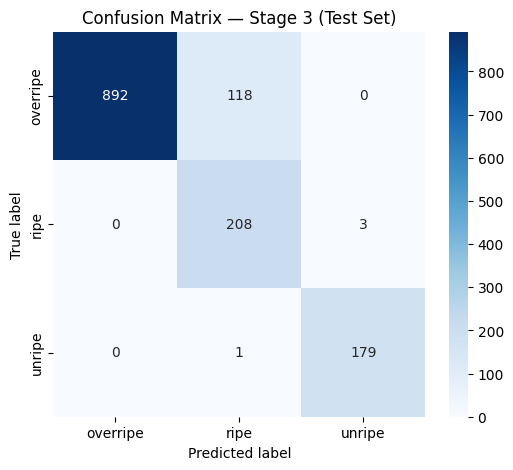

In [ ]:
# CONFUSION MATRIX FOR STAGE 3(test set)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_3 = confusion_matrix(y_true_3, y_pred_3)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Stage 3 (Test Set)")
plt.show()

**BEST ACCURACY: STAGE-2**

#